In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset/alzheimers_disease_data.csv


# Alzheimer's Disease Diagnosis Prediction

This notebook loads a tabular dataset of 2,149 older adults (ages 60-90) and builds classifiers that predict a binary **Diagnosis** label (0 = no Alzheimer's diagnosis, 1 = diagnosis). It moves through data checks, exploratory plots, three models of increasing flexibility (Logistic Regression, Random Forest, XGBoost), model interpretation, and a final experiment that removes the clinical assessment variables.

**How to read this notebook.** Each code cell that produces a visible result is preceded by a short description of what the code does and followed by an **Interpretation** of the result. Cells that produce no visible output are left as they were. Cells are numbered 1-48 by their position in the notebook. Your original code and outputs have not been changed.

**Headline result.** XGBoost is the strongest model (test accuracy 0.954, F1 0.933, ROC-AUC 0.949). Almost all of the predictive signal comes from five variables: FunctionalAssessment, ADL, MMSE, MemoryComplaints and BehavioralProblems. Lifestyle, demographic and medical-history variables carry almost no signal in this dataset (Cells 44-46).

## Part 1: Setup, data loading and data-quality checks

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# For data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler

In [22]:
data = pd.read_csv('/kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset/alzheimers_disease_data.csv')
pd.set_option('display.max_columns', None)
data.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [24]:
data.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

In [25]:
data.shape

(2149, 35)

In [26]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
PatientID,2149.0,5825.000000,620.507185,4751.000000,5288.000000,5825.000000,6362.000000,6899.000000
Age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
Gender,2149.0,0.506282,0.500077,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2149.0,0.697534,0.996128,0.000000,0.000000,0.000000,1.000000,3.000000
EducationLevel,2149.0,1.286645,0.904527,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
Smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346


> **Interpretation.** - **Age** ranges 60-90 (mean 74.9). **BMI** ranges 15-40 (mean 27.7).
> - **MMSE** (a 0-30 cognitive score) has a mean of 14.8, far lower than typical community populations, and spans the full 0-30 range.
> - **FunctionalAssessment** and **ADL** are 0-10 scores with means near 5.
> - Binary flags show prevalence: family history 25%, smoking 29%, depression 20%, memory complaints 21%, forgetfulness 30%.
> - **Diagnosis** has a mean of 0.354, so about 35% of patients are positive.
> - Many continuous variables (alcohol 0-20, physical activity 0-10, diet quality 0-10, systolic BP 90-179, total cholesterol 150-300) have means close to the midpoint of their range and quartiles evenly spaced. That uniform pattern is common in **synthetic** data, so it is worth confirming where the dataset came from before generalizing to real patients.

In [27]:
data.duplicated().sum()

np.int64(0)

In [28]:
data['Diagnosis'].mean()

np.float64(0.35365286179618427)

#### Drop identifier columns

> Removes `DoctorInCharge` and `PatientID`, which are identifiers rather than clinical features and could only add noise (or leak patient- or clinic-level patterns). `errors='ignore'` prevents a failure if a column is already gone, and `inplace=True` modifies `data` directly.

In [29]:
data.drop(
    columns=['DoctorInCharge', 'PatientID'],
    errors='ignore',
    inplace=True
)
data.head(10)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0
5,86,1,1,1,30.626886,0,4.140144,0.211062,1.584922,7.261953,0,0,1,0,0,0,168,62,280.712539,198.334629,79.080503,263.943655,27.517529,5.510144,0,0,9.015686,1,0,0,0,0,0
6,68,0,3,2,38.387622,1,0.646047,9.257695,5.897388,5.477686,0,0,0,0,1,0,143,88,263.734149,52.470670,66.533369,216.489175,1.964413,6.062124,0,0,9.236328,0,0,0,0,1,0
7,75,0,0,1,18.776009,0,13.723826,4.649451,8.341903,4.213210,0,0,0,0,0,0,117,63,151.383137,69.623510,77.346816,210.570866,10.139568,3.401374,0,0,4.517248,1,0,0,0,1,1
8,72,1,1,0,27.833188,0,12.167848,1.531360,6.736882,5.748224,0,0,0,0,0,1,117,119,233.605755,144.045740,43.075893,151.164186,25.820732,7.396061,0,1,0.756232,0,0,1,0,0,0
9,87,0,0,0,35.456302,1,16.028688,6.440773,8.086019,7.551773,0,1,0,0,0,0,130,78,281.630050,130.497580,74.291247,144.175975,28.388409,1.148904,0,1,4.554394,0,0,0,0,0,0


In [30]:
cols = ['Diagnosis'] + [col for col in data.columns if col != 'Diagnosis']
data = data[cols]
data.head(10)

,Diagnosis,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0
1,0,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1
2,0,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0
3,0,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0
4,0,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0
5,0,86,1,1,1,30.626886,0,4.140144,0.211062,1.584922,7.261953,0,0,1,0,0,0,168,62,280.712539,198.334629,79.080503,263.943655,27.517529,5.510144,0,0,9.015686,1,0,0,0,0
6,0,68,0,3,2,38.387622,1,0.646047,9.257695,5.897388,5.477686,0,0,0,0,1,0,143,88,263.734149,52.470670,66.533369,216.489175,1.964413,6.062124,0,0,9.236328,0,0,0,0,1
7,1,75,0,0,1,18.776009,0,13.723826,4.649451,8.341903,4.213210,0,0,0,0,0,0,117,63,151.383137,69.623510,77.346816,210.570866,10.139568,3.401374,0,0,4.517248,1,0,0,0,1
8,0,72,1,1,0,27.833188,0,12.167848,1.531360,6.736882,5.748224,0,0,0,0,0,1,117,119,233.605755,144.045740,43.075893,151.164186,25.820732,7.396061,0,1,0.756232,0,0,1,0,0
9,0,87,0,0,0,35.456302,1,16.028688,6.440773,8.086019,7.551773,0,1,0,0,0,0,130,78,281.630050,130.497580,74.291247,144.175975,28.388409,1.148904,0,1,4.554394,0,0,0,0,0


## Part 2: Exploratory data analysis


Value Counts:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Value Counts (Percentage):
Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64


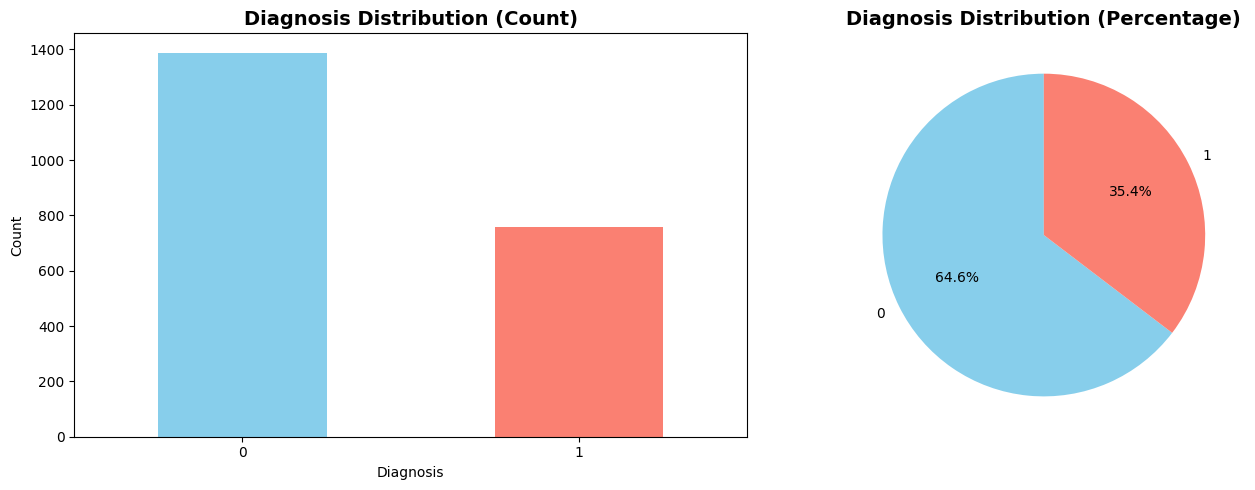

In [31]:
target_column = 'Diagnosis'  

print("\nValue Counts:")
print(data[target_column].value_counts())

print("\nValue Counts (Percentage):")
print(data[target_column].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data[target_column].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title(f'{target_column} Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel(target_column)
axes[0].tick_params(axis='x', rotation=0)

data[target_column].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                      colors=['skyblue', 'salmon'], startangle=90)
axes[1].set_title(f'{target_column} Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

> **Interpretation.** - **1,389 patients (64.6%) are negative** and **760 (35.4%) are positive**.
> - The bar chart shows the negative bar roughly 1.8 times the height of the positive bar; the pie shows the same split.
> - This is a mild imbalance. It is why the modelling section relies on **F1, recall and ROC-AUC** rather than accuracy alone, and why the train/test split is stratified in Cell 21.

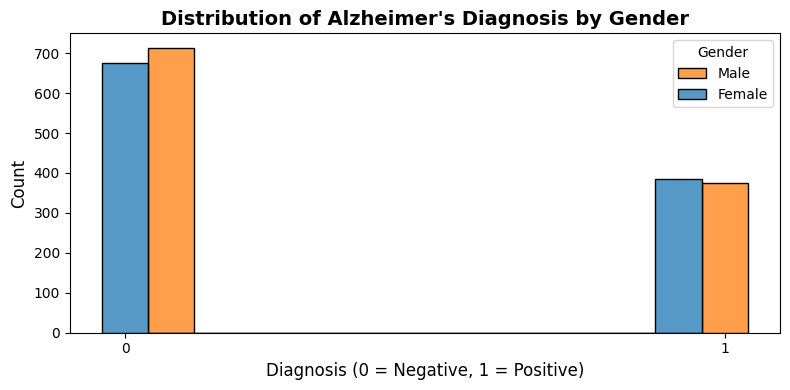

In [32]:
plt.figure(figsize=(8, 4))
sns.histplot(data=data, x='Diagnosis', hue='Gender', multiple='dodge', shrink=2)

plt.title('Distribution of Alzheimer\'s Diagnosis by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis (0 = Negative, 1 = Positive)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1])
plt.legend(title='Gender', labels=['Male', 'Female'])  # adjust order/labels to match your actual coding
plt.tight_layout()
plt.show()

> **Interpretation.** Positive and negative counts are nearly identical for the two genders (roughly 675 vs 715 negative and 385 vs 375 positive, about a 36% vs 34% positive rate). **Gender shows no meaningful association with diagnosis.**
>
> **Check the legend:** seaborn draws Gender 0 in blue and Gender 1 in orange, but the manual legend labels blue as 'Female' and orange as 'Male'. In the dataset's documentation Gender 0 is usually Male and 1 is Female, so the labels may be swapped. It does not affect any modelling result, but it is worth fixing before sharing the chart.

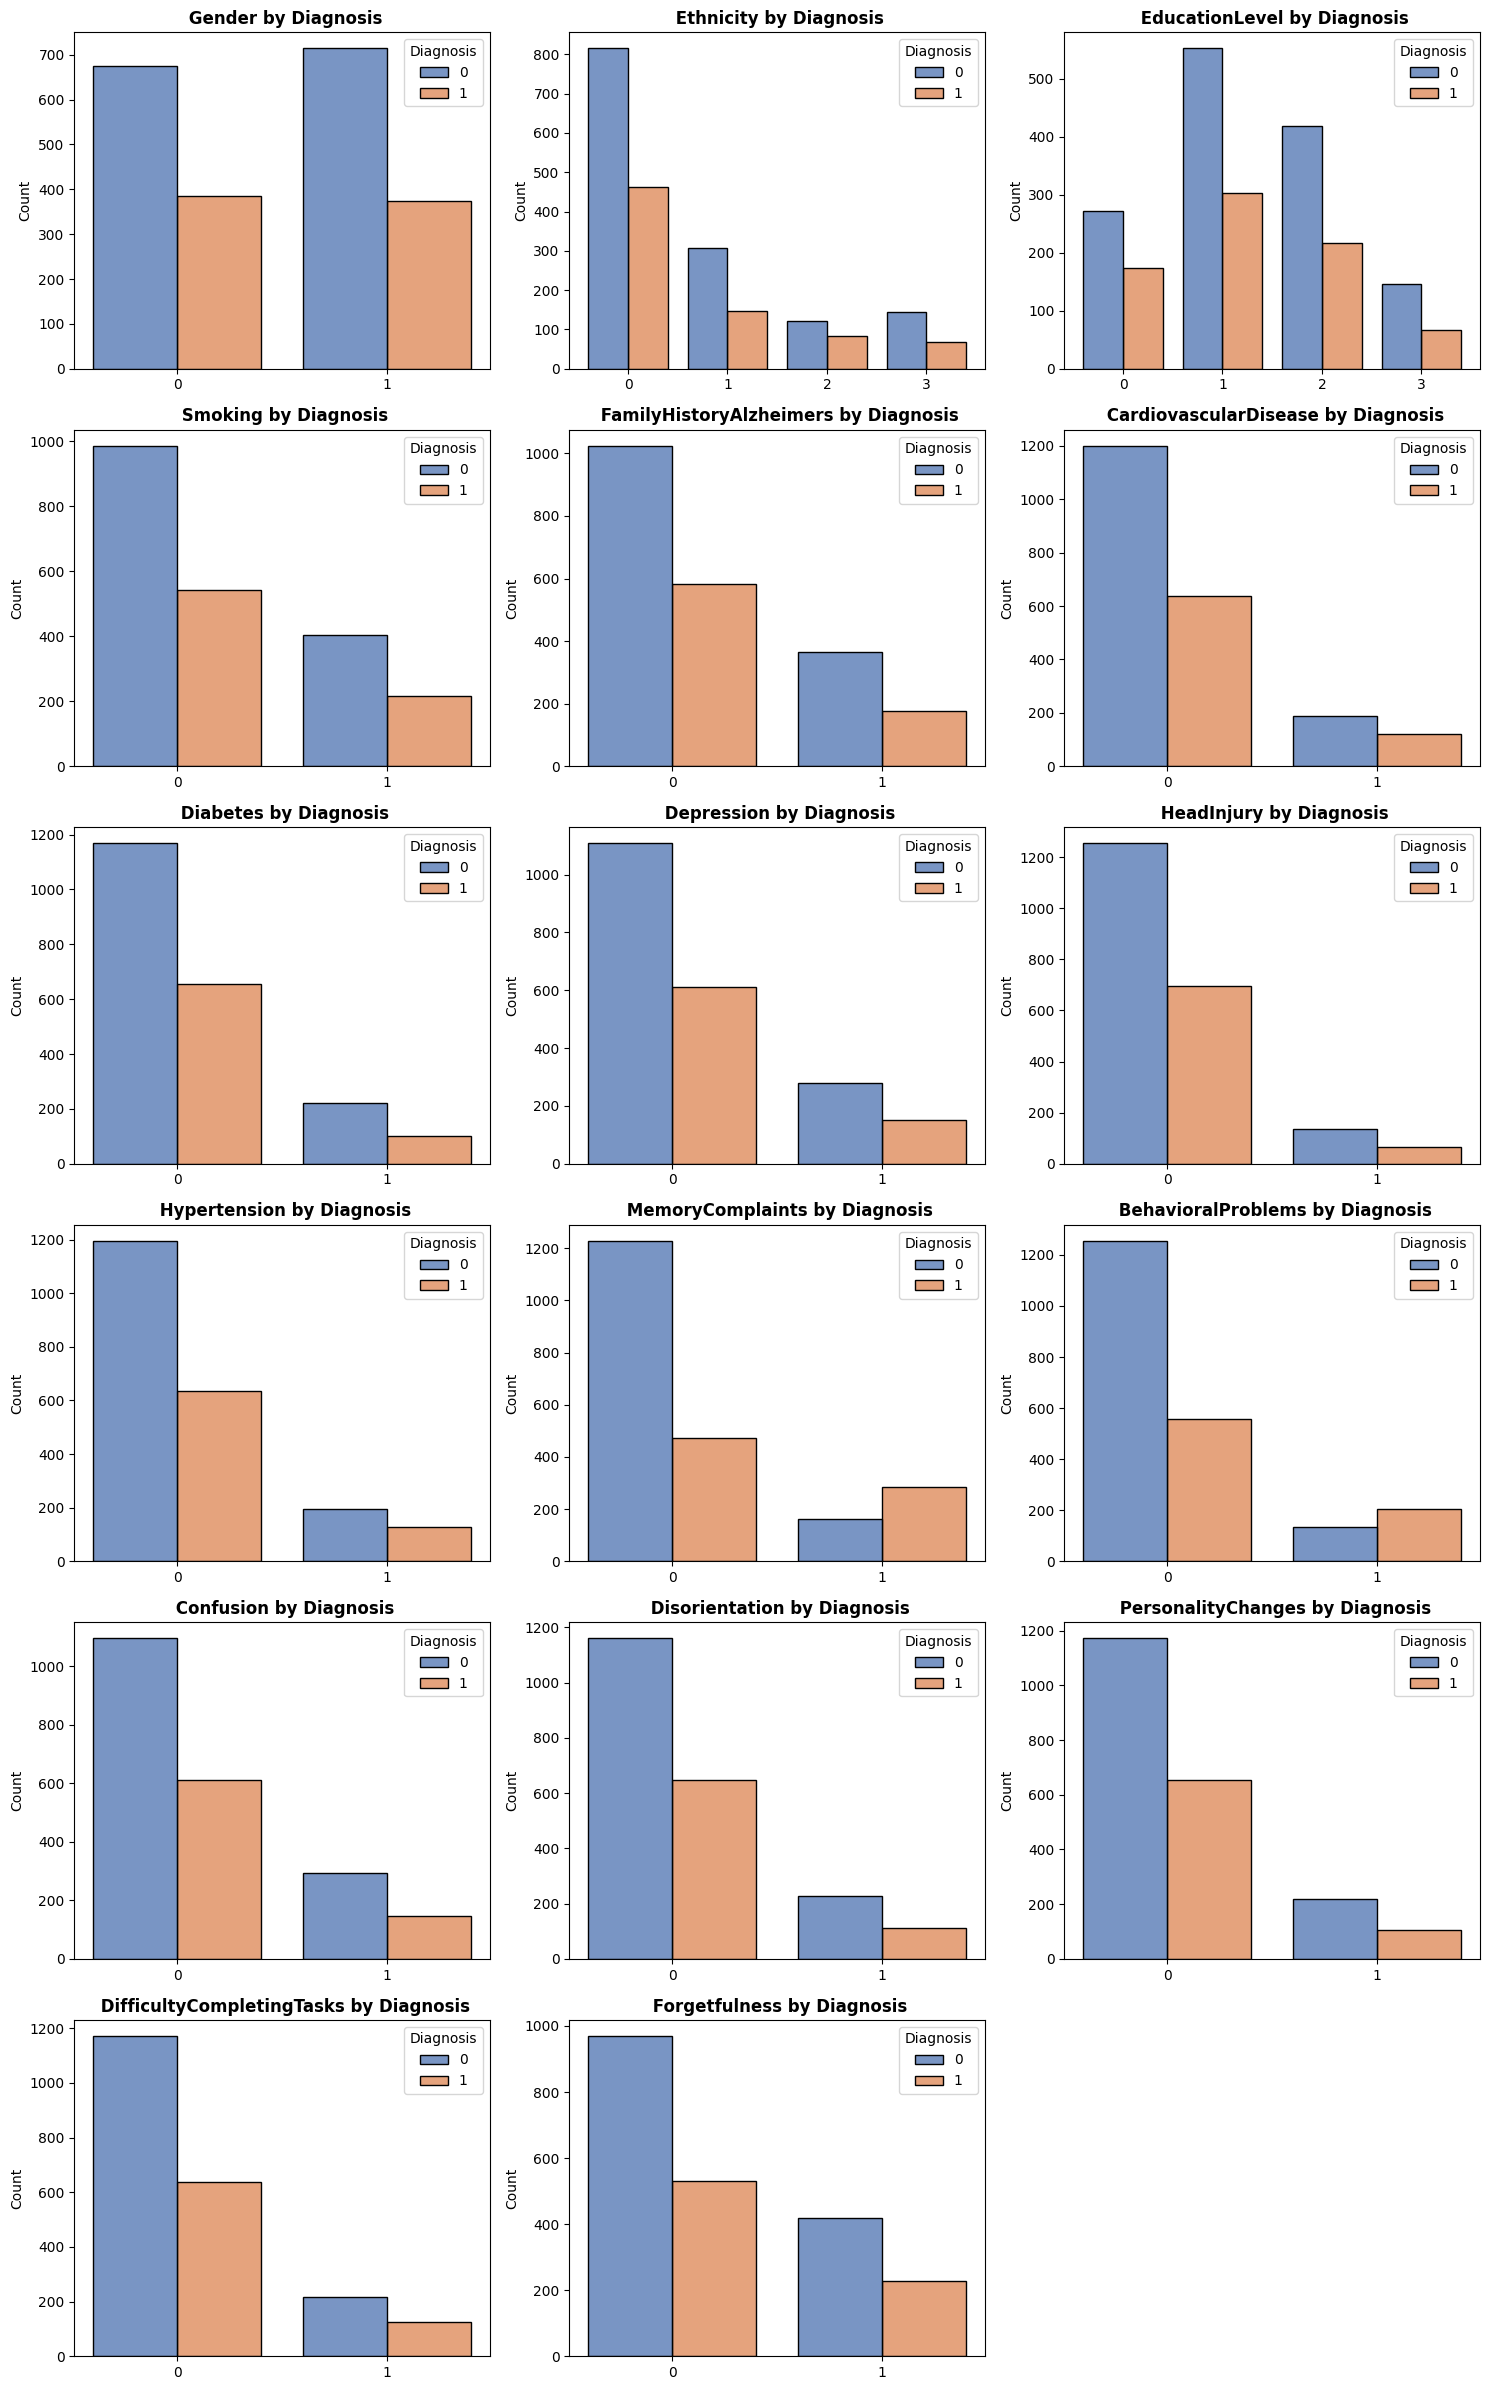

In [33]:
import math

diagnosis_palette = ['#4C72B0', '#DD8452']

def plot_all_hist_by_diagnosis(df, target='Diagnosis', title_prefix=""):
    cat_cols = [col for col in df.columns if df[col].nunique() <= 10 and col != target]
    n_cols = 3
    n_rows = math.ceil(len(cat_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))
    for i, col in enumerate(cat_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(
            data=df, x=col, hue=df[target].astype(str),
            multiple='dodge', palette=diagnosis_palette,
            discrete=True,      # one bin per unique value
            shrink=0.8,         # bar width as a fraction of the slot
        )
        plt.xticks(sorted(df[col].dropna().unique()))  # only real category values
        plt.title(f"{title_prefix} {col} by {target}", fontsize=12, fontweight='bold')
        plt.xlabel("")
    plt.tight_layout()
    plt.show()

plot_all_hist_by_diagnosis(data)

> **Interpretation.** - The grid now has **19 panels**: Ethnicity is shown as Ethnicity_1, Ethnicity_2 and Ethnicity_3 (True/False indicators). If the cell is run in notebook order, before the encoding, you would instead get 17 panels with a single Ethnicity chart.
> - For most variables (Gender, EducationLevel, Smoking, FamilyHistoryAlzheimers, CardiovascularDisease, Diabetes, Depression, HeadInjury, Hypertension, Confusion, Disorientation, PersonalityChanges, DifficultyCompletingTasks, Forgetfulness and the Ethnicity indicators) the negative bar is roughly twice the positive bar in every category. **These variables show little visible association with diagnosis.**
> - **MemoryComplaints** and **BehavioralProblems** stand out: among patients with the flag set to 1, positives outnumber negatives (roughly 285 vs 160 for memory complaints and 205 vs 135 for behavioural problems), the reverse of the overall pattern.
> - The bars are now wide and readable, which fixes the thin-bar problem in the earlier version of this chart.

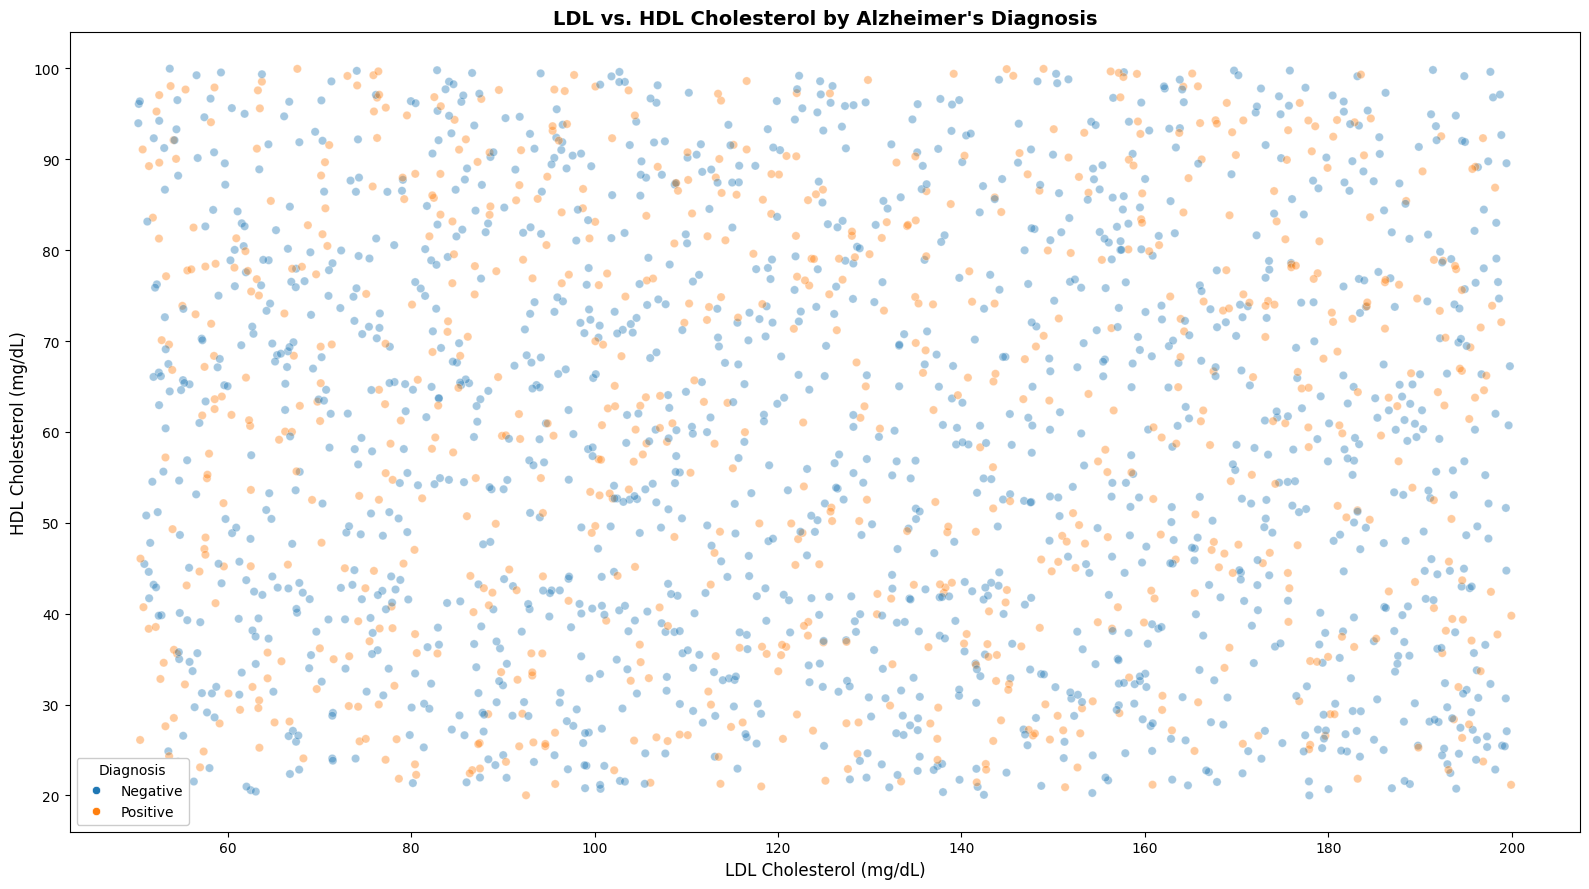

In [34]:
plt.figure(figsize=(16, 9))
ax = sns.scatterplot(data=data, x='CholesterolLDL', y='CholesterolHDL', 
                 hue=data['Diagnosis'].astype(str), alpha=0.4)
plt.title('LDL vs. HDL Cholesterol by Alzheimer\'s Diagnosis', fontsize=14, fontweight='bold')
plt.xlabel('LDL Cholesterol (mg/dL)', fontsize=12)
plt.ylabel('HDL Cholesterol (mg/dL)', fontsize=12)
legend = ax.legend_
legend.set_title('Diagnosis')

new_labels = ['Negative', 'Positive']
for text, label in zip(legend.texts, new_labels):
    text.set_text(label)

for handle in legend.legend_handles:
    handle.set_alpha(1)

legend.get_frame().set_alpha(1)

plt.tight_layout()
plt.show()

> **Interpretation.** Blue (negative) and orange (positive) points are thoroughly mixed across the whole rectangle (LDL 50-200, HDL 20-100). There is no visible cluster, boundary or trend, so **these two cholesterol measures do not separate the classes**, and they also look unrelated to each other, which is unusual for real lipid data.

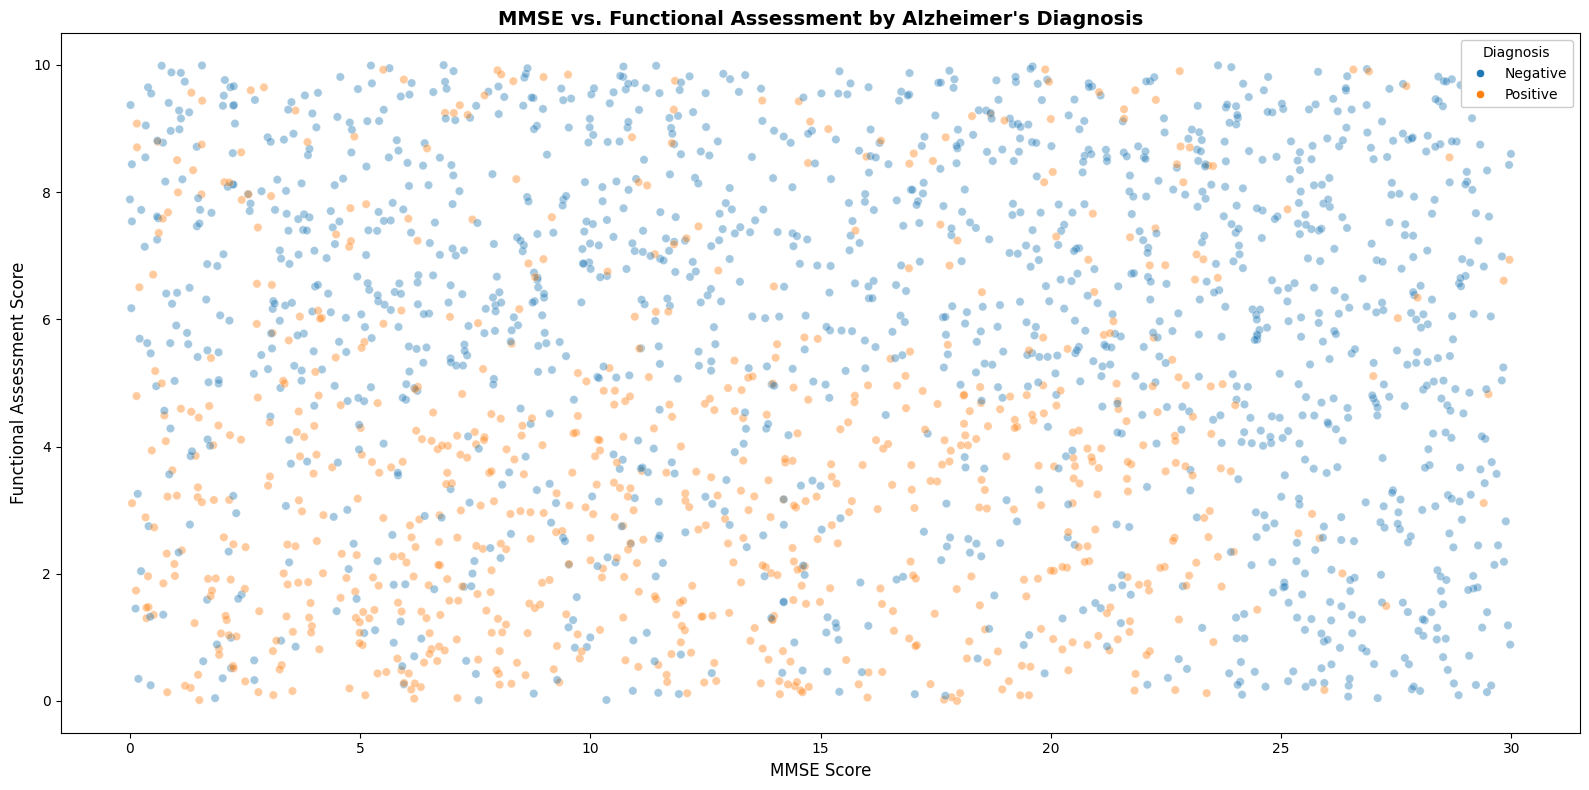

In [35]:

plt.figure(figsize=(16, 8))
ax = sns.scatterplot(data=data, x='MMSE', y='FunctionalAssessment',
                      hue=data['Diagnosis'].astype(str), alpha=0.4)
plt.title('MMSE vs. Functional Assessment by Alzheimer\'s Diagnosis', fontsize=14, fontweight='bold')
plt.xlabel('MMSE Score', fontsize=12)
plt.ylabel('Functional Assessment Score', fontsize=12)

legend = ax.legend_
legend.set_title('Diagnosis')

new_labels = ['Negative', 'Positive']
for text, label in zip(legend.texts, new_labels):
    text.set_text(label)

for handle in legend.legend_handles:
    handle.set_alpha(1)

legend.get_frame().set_alpha(1)

plt.tight_layout()
plt.show()

> **Interpretation.** There is a clear pattern. **Positive cases (orange) concentrate in the lower half of the plot, at Functional Assessment below about 5,** while patients with high functional scores are almost all negative. MMSE separates the groups less sharply: positives appear across the whole 0-30 range but are denser at low and middle MMSE. The bottom-left region (low functional score and low MMSE) is the most positive-heavy. The classes overlap considerably, so no single variable perfectly separates them.

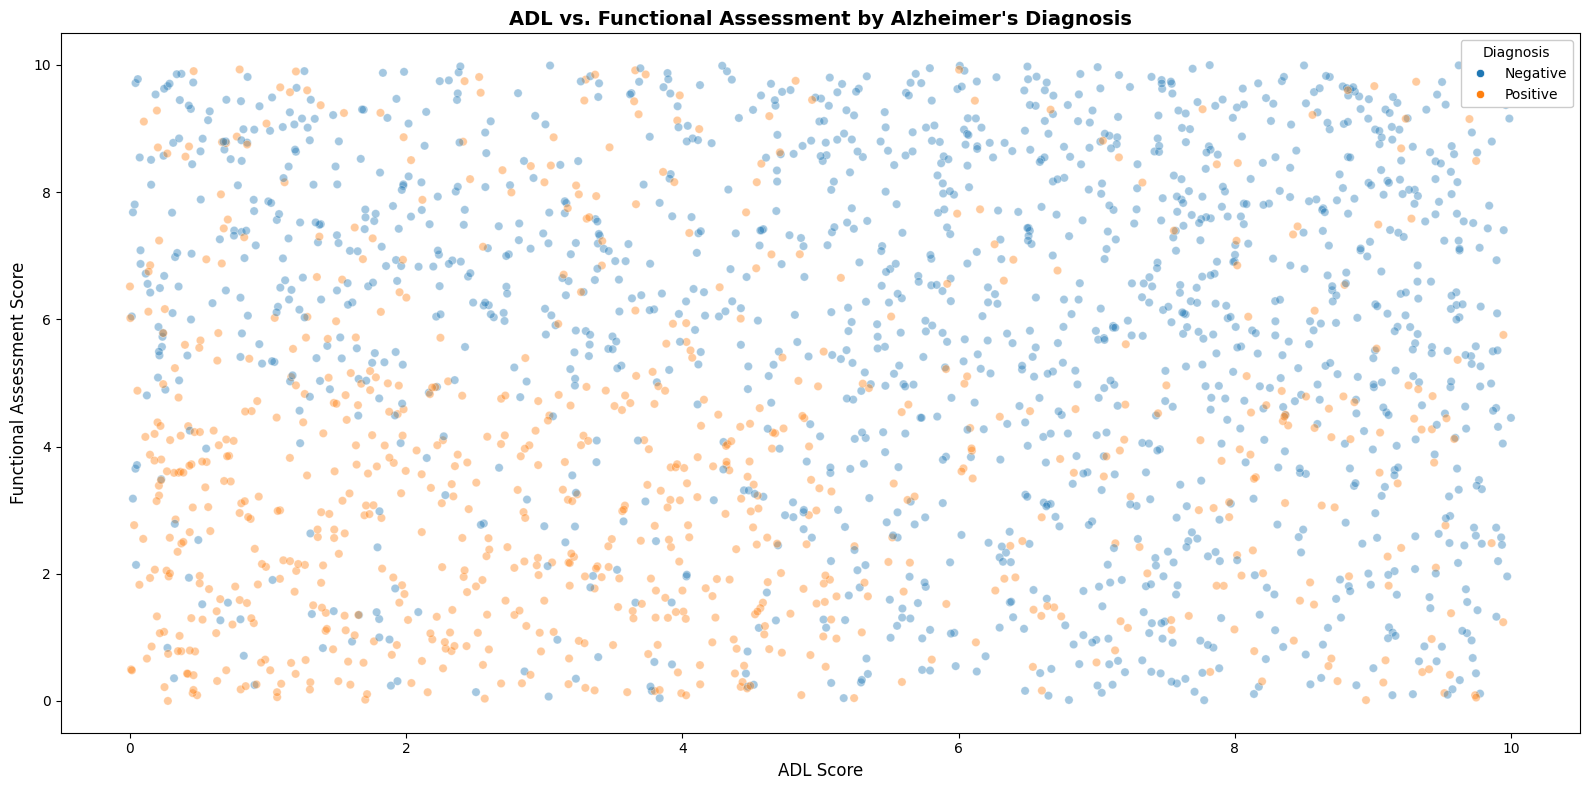

In [36]:
plt.figure(figsize=(16, 8))
ax= sns.scatterplot(data=data, x='ADL', y='FunctionalAssessment', 
                 hue=data['Diagnosis'].astype(str), alpha=0.4)
plt.title('ADL vs. Functional Assessment by Alzheimer\'s Diagnosis', fontsize=14, fontweight='bold')
plt.xlabel('ADL Score', fontsize=12)
plt.ylabel('Functional Assessment Score', fontsize=12)
legend = ax.legend_
legend.set_title('Diagnosis')

new_labels = ['Negative', 'Positive']
for text, label in zip(legend.texts, new_labels):
    text.set_text(label)

for handle in legend.legend_handles:
    handle.set_alpha(1)

legend.get_frame().set_alpha(1)

plt.tight_layout()
plt.show()

> **Interpretation.** Positives cluster in the **lower-left corner (low ADL and low functional score)**, and the right-hand side (ADL above about 6) is mostly negative. Both scores measure day-to-day functioning, and a combination of the two separates the classes better than either alone. This foreshadows the decision tree in Cell 42, which splits on exactly these variables.

In [37]:
data['Ethnicity'].value_counts()

Ethnicity
0    1278
1     454
3     211
2     206
Name: count, dtype: int64

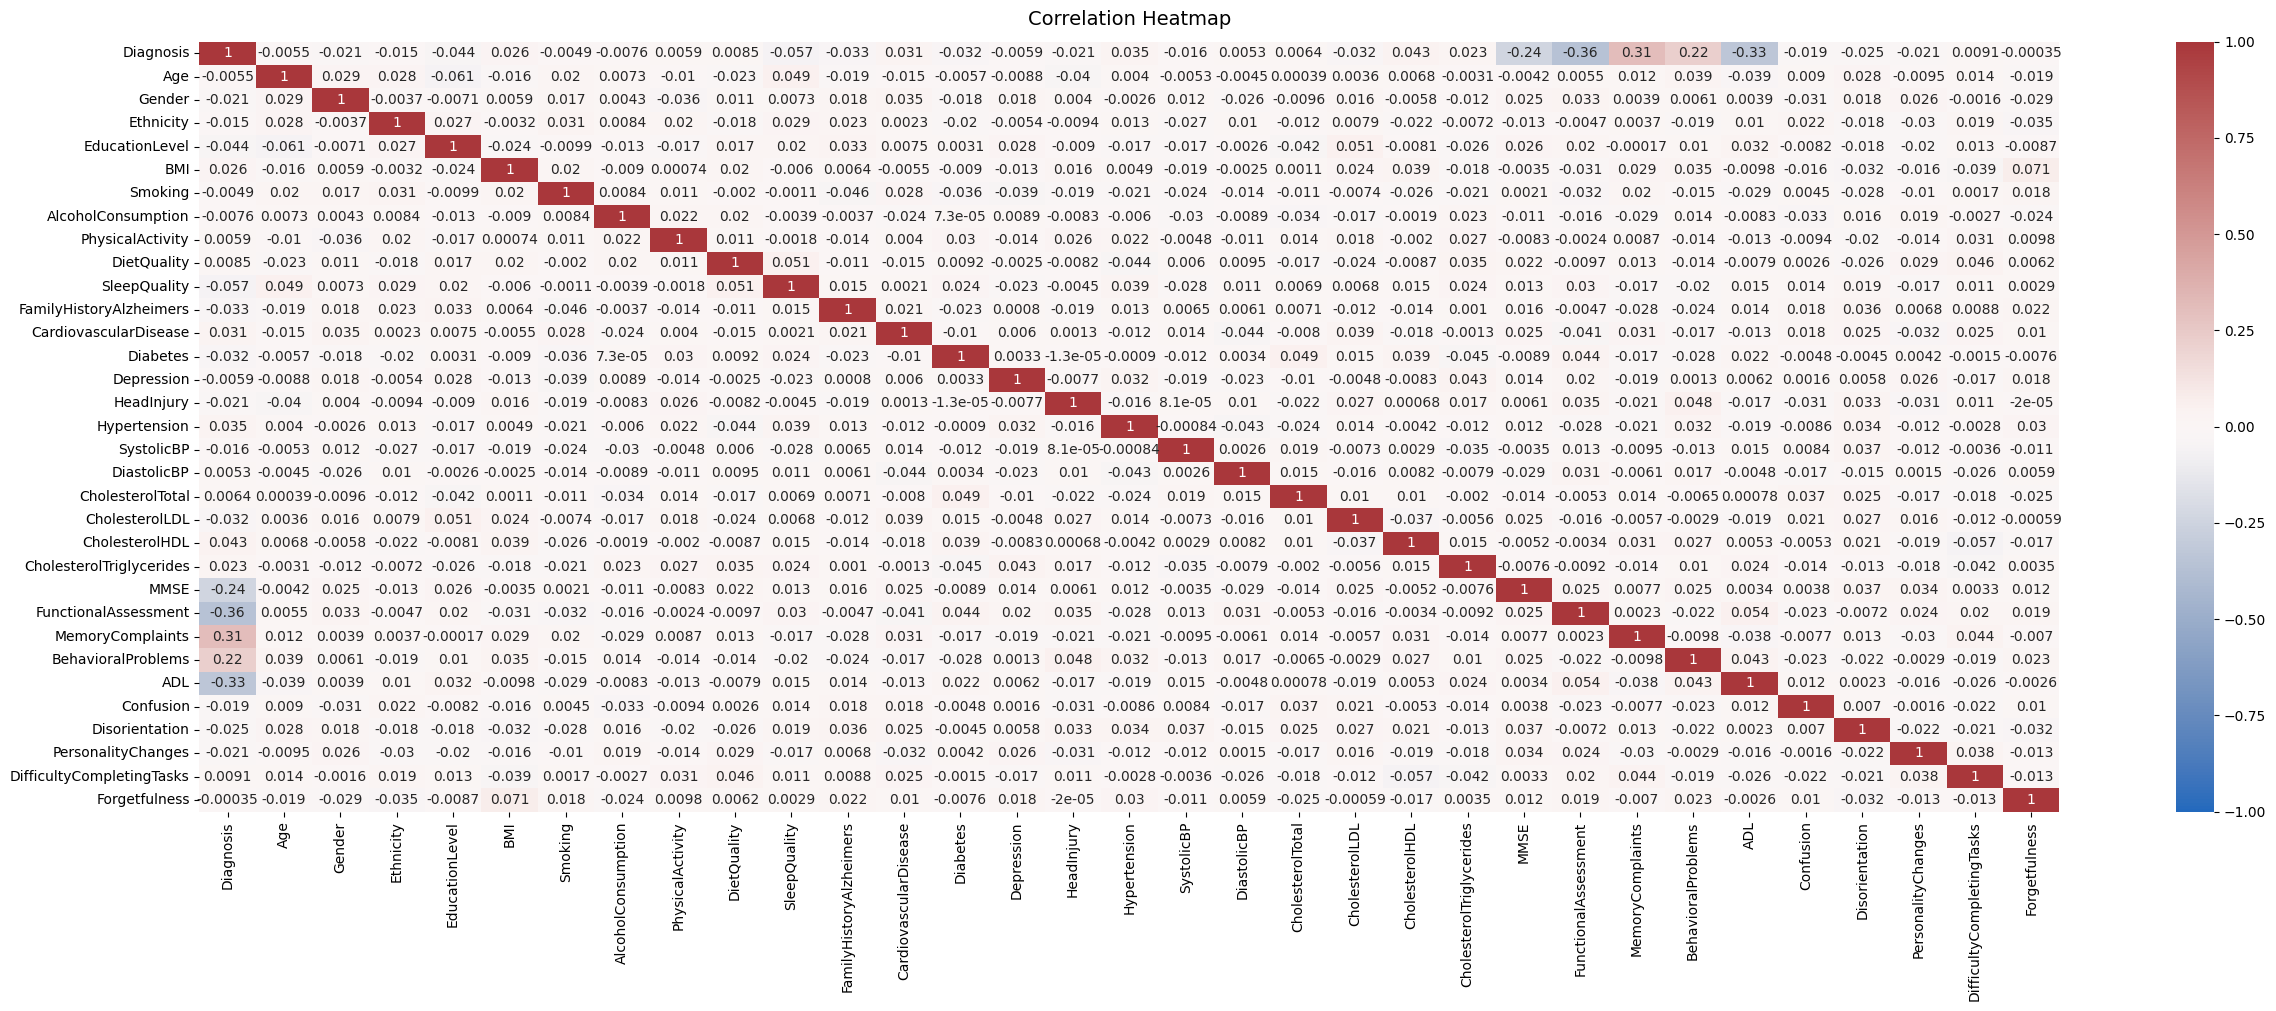

In [38]:
plt.figure(figsize=(30, 10))
heatmap = sns.heatmap(data.corr(), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

> **Interpretation.** - Correlations with **Diagnosis**: FunctionalAssessment **-0.36**, ADL **-0.33**, MemoryComplaints **+0.31**, MMSE **-0.24**, BehavioralProblems **+0.22**. Higher functional, ADL and MMSE scores go with a lower chance of diagnosis, while memory complaints and behavioural problems go with a higher chance.
> - Every other variable has an absolute correlation below about 0.06 with Diagnosis, including **Age (-0.005)**, which is surprising because age is the strongest known real-world risk factor.
> - The predictors are almost uncorrelated with each other (the heatmap is nearly white off the diagonal), so multicollinearity is not a concern, though this is again unusually clean for real clinical data.
> - Ethnicity is still a numeric code here, so its correlation values are not meaningful for a nominal variable.

## Part 3: Preprocessing and train/test split (Cells 20-22)

#### One-hot encode Ethnicity

> `pd.get_dummies(..., drop_first=True)` replaces the single Ethnicity column with three True/False indicator columns (Ethnicity_1, _2, _3). Category 0 is dropped and serves as the reference group, avoiding a redundant column.

In [39]:
data = pd.get_dummies(data,  columns=['Ethnicity'], drop_first=True)
data.head()

,Diagnosis,Age,Gender,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Ethnicity_1,Ethnicity_2,Ethnicity_3
0,0,73,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,False,False,False
1,0,89,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,False,False,False
2,0,73,0,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,False,False,True
3,0,74,1,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,False,False,False
4,0,89,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,False,False,False


In [40]:
model_data = data.copy()
y = model_data['Diagnosis']
X = model_data.drop(columns='Diagnosis')

Xtrain,Xtest, ytrain, ytest = train_test_split(X,y, test_size=0.25, stratify= y, random_state=42)

In [41]:
scaler =StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

> **Interpretation.** - Standardises the features so each has mean 0 and standard deviation 1. The scaler learns the means and standard deviations from the training set only (fit_transform), then applies those same values to the test set (transform).

## Part 4: Model 1 - Logistic Regression

In [42]:
clf = LogisticRegression(random_state= 42, max_iter=1000)
log_model = clf.fit(Xtrain_scaled, ytrain)

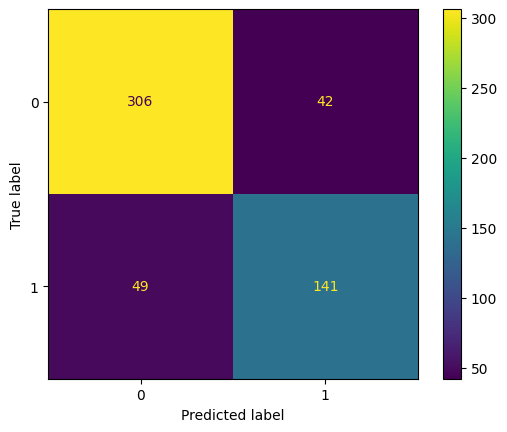

In [43]:
y_pred = log_model.predict(Xtest_scaled)

cm = confusion_matrix(ytest, y_pred, labels = clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)
disp.plot()

> **Interpretation.** - **306** true negatives, **141** true positives.
> - **42** false positives (healthy patients flagged as diagnosed) and **49** false negatives (diagnosed patients missed).
> - Roughly a quarter of real positives (49 of 190) are missed. The line of text `<ConfusionMatrixDisplay ...>`

In [44]:
print('F1 score logistic regression: ', f1_score(ytest, y_pred))
print('Recall score logistic regression: ', recall_score(ytest, y_pred))
print('Precision score logistic regression: ', precision_score(ytest, y_pred))
print('Accuracy score logistic regression: ', accuracy_score(ytest, y_pred))

F1 score logistic regression:  0.7560321715817694
Recall score logistic regression:  0.7421052631578947
Precision score logistic regression:  0.7704918032786885
Accuracy score logistic regression:  0.8308550185873605


> **Interpretation.** - **Accuracy 0.831**: about 83% of all predictions are right.
> - **Precision 0.770**: when the model says 'diagnosed', it is right 77% of the time.
> - **Recall 0.742**: it finds 74% of the truly diagnosed patients.
> - **F1 0.756**: the balance of precision and recall.
>
> These numbers reconcile with the confusion matrix (141 / (141 + 49) = 0.742 recall). Accuracy is well above the 65% majority-class baseline, so the model has real signal, but a quarter of positives are missed.

In [45]:
logreg_cv_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear supports both l1 and l2
}

scoring = ['accuracy', 'precision', 'recall', 'f1']

logreg_cv = GridSearchCV(clf, logreg_cv_params, scoring=scoring, cv=5, refit='f1')
logreg_cv.fit(Xtrain_scaled, ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             refit='f1', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [46]:
logreg_cv_preds = logreg_cv.predict(Xtest_scaled)
print('F1 score Logistic Regression CV:', f1_score(ytest, logreg_cv_preds))
print('Recall score Logistic Regression CV:', recall_score(ytest, logreg_cv_preds))
print('Precision score Logistic Regression CV:', precision_score(ytest, logreg_cv_preds))
print('Accuracy score Logistic Regression CV:', accuracy_score(ytest, logreg_cv_preds))

F1 score Logistic Regression CV: 0.7573333333333333
Recall score Logistic Regression CV: 0.7473684210526316
Precision score Logistic Regression CV: 0.7675675675675676
Accuracy score Logistic Regression CV: 0.8308550185873605


> **Interpretation.** F1 0.757, recall 0.747, precision 0.768 and accuracy 0.831 are essentially identical to the untuned model in Cell 25 (F1 0.756, accuracy 0.831). **Tuning added almost nothing**, which suggests the limit is the linear form of the model rather than its regularization.

In [47]:
def make_results(model_name, model_object):
    '''
    Accepts as arguments a model name (your choice - string) and
    a fit GridSearchCV model object.
  
    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean F1 score across all validation folds.  
    '''

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(mean f1 score)
    best_estimator_results = cv_results.iloc[cv_results['mean_test_f1'].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                          'F1': [f1],
                          'Recall': [recall],
                          'Precision': [precision],
                          'Accuracy': [accuracy]
                         }
                        )
  
    return table

In [48]:
logistic_regression_cv_results = make_results('logistic Regression CV', logreg_cv)
logistic_regression_cv_results

,Model,F1,Recall,Precision,Accuracy
0,logistic Regression CV,0.767841,0.738596,0.803018,0.841698


> **Interpretation.** Mean 5-fold validation scores: **F1 0.768, recall 0.739, precision 0.803, accuracy 0.842**. These come from the training data only and are close to the test scores in Cell 27 (F1 0.757), which indicates the model is not overfitting.

## Part 5: Model 2 - Random Forest

#### Fit the Random Forest search

> Runs the grid search on the unscaled training data (trees are insensitive to feature scale). The best model by F1 is refit on all training data.

In [49]:
randomforest = RandomForestClassifier(random_state=42)


rf_cv_params = {'max_depth': [4,5,6,7], 
             'min_samples_split': [3,5,7,10],
             'min_samples_leaf': [1, 3, 5],
             'n_estimators': [100, 150, 200],
             }    

scoring = ['accuracy', 'precision', 'recall', 'f1']

randomforest = GridSearchCV(randomforest, rf_cv_params, scoring=scoring, cv=5, refit='f1')
randomforest.fit(Xtrain, ytrain)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [4, 5, 6, 7],
                         'min_samples_leaf': [1, 3, 5],
                         'min_samples_split': [3, 5, 7, 10],
                         'n_estimators': [100, 150, 200]},
             refit='f1', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [50]:
rf_preds = randomforest.predict(Xtest)
print('F1 score Random Forest:', f1_score(ytest, rf_preds))
print('Recall score Random Forest:', recall_score(ytest, rf_preds))
print('Precision score Random Forest:', precision_score(ytest, rf_preds))
print('Accuracy score Random Forest:', accuracy_score(ytest, rf_preds))

F1 score Random Forest: 0.8838526912181303
Recall score Random Forest: 0.8210526315789474
Precision score Random Forest: 0.9570552147239264
Accuracy score Random Forest: 0.9237918215613383


> **Interpretation.** **F1 0.884, recall 0.821, precision 0.957, accuracy 0.924.** This is a large jump over Logistic Regression (F1 0.757), so non-linear effects and interactions, such as thresholds on functional scores, matter. Precision is very high (96% of flagged patients are truly positive), while recall (82%) shows about 18% of true positives are still missed.

In [51]:
randomforest_results = make_results('Randomforest CV', randomforest)
randomforest_results

,Model,F1,Recall,Precision,Accuracy
0,Randomforest CV,0.868601,0.796491,0.956453,0.914949


> **Interpretation.** F1 0.869, recall 0.796, precision 0.956, accuracy 0.915. These are consistent with the test results in Cell 32 (F1 0.884), so the performance looks stable.

In [52]:
results = pd.concat([logistic_regression_cv_results, randomforest_results]).sort_values(by=['F1'], 
                                                           ascending=False)
results

,Model,F1,Recall,Precision,Accuracy
0,Randomforest CV,0.868601,0.796491,0.956453,0.914949
0,logistic Regression CV,0.767841,0.738596,0.803018,0.841698


## Part 6: Model 3 - XGBoost

In [53]:
xgb = XGBClassifier(objective='binary:logistic', random_state=0) 

cv_params = {'max_depth': [4,5,6,7], 
             'min_child_weight': [3,5,7,10],
             'learning_rate': [0.01, 0.03, 0.05, 0.1],
             'n_estimators': [100, 150, 200],
             }    

scoring = ['accuracy', 'precision', 'recall', 'f1']

xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='f1')

In [54]:
xgb_cv.fit(Xtrain, ytrain)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.03, 0.05, 0.1],
                         'max_depth': [4, 5, 6, 7],
                         'min_child_weight': [3, 5, 7, 10],
                         'n_estimators': [100, 150, 200]},
             refit='f1', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [55]:
xgb_cv_results = make_results('XGBoost CV', xgb_cv)
xgb_cv_results

,Model,F1,Recall,Precision,Accuracy
0,XGBoost CV,0.927791,0.915789,0.941185,0.949724


> **Interpretation.** **F1 0.928, recall 0.914, precision 0.944, accuracy 0.950.** XGBoost improves on Random Forest mostly through recall (0.914 vs 0.796) while keeping precision similar.

In [56]:
results = pd.concat([results, xgb_cv_results]).sort_values(by=['F1'], 
                                                           ascending=False)

results = results.reset_index(drop=True)
results

,Model,F1,Recall,Precision,Accuracy
0,XGBoost CV,0.927791,0.915789,0.941185,0.949724
1,Randomforest CV,0.868601,0.796491,0.956453,0.914949
2,logistic Regression CV,0.767841,0.738596,0.803018,0.841698


In [57]:
# Predict on test data
xgb_cv_preds = xgb_cv.predict(Xtest)
print('F1 score final XGB model: ', f1_score(ytest, xgb_cv_preds))
print('Recall score final XGB model: ', recall_score(ytest, xgb_cv_preds))
print('Precision score final XGB model: ', precision_score(ytest, xgb_cv_preds))
print('Accuracy score final XGB model: ', accuracy_score(ytest, xgb_cv_preds))

F1 score final XGB model:  0.9361702127659575
Recall score final XGB model:  0.9263157894736842
Precision score final XGB model:  0.946236559139785
Accuracy score final XGB model:  0.9553903345724907


> **Interpretation.** **F1 0.936, recall 0.926, precision 0.946, accuracy 0.955.** These are very close to the cross-validation values (F1 0.928), so the model generalizes well to unseen patients and there is no sign of overfitting to the training data. This is the notebook's best model.

In [58]:
def conf_matrix_plot(model, x_data, y_data):
    '''
    Accepts as argument model object, X data (test or validate), and y data (test or validate). 
    Returns a plot of confusion matrix for predictions on y data.
    ''' 
    model_pred = model.predict(x_data)
    cm = confusion_matrix(y_data, model_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=model.classes_)
  
    disp.plot()
    plt.show()

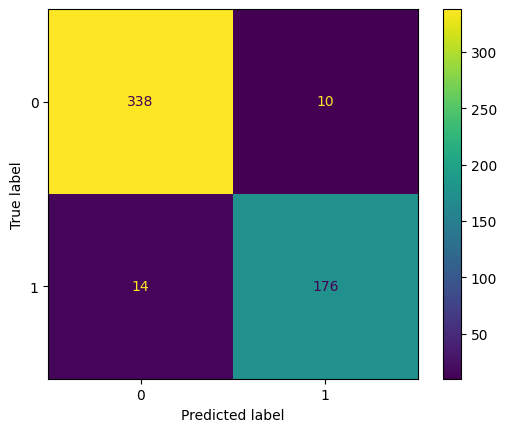

In [59]:
conf_matrix_plot(xgb_cv, Xtest, ytest)

> **Interpretation.** - **339** true negatives and **174** true positives.
> - Only **10 false positives** (2.8% of the 348 healthy patients) and **14 false negatives** (7.4% of the 190 diagnosed patients).
> - 25 errors out of 538 predictions, compared with 91 errors for Logistic Regression in Cell 24. Missing 16 real cases is the main remaining weakness if this were used for screening.

## Part 7: Model interpretation

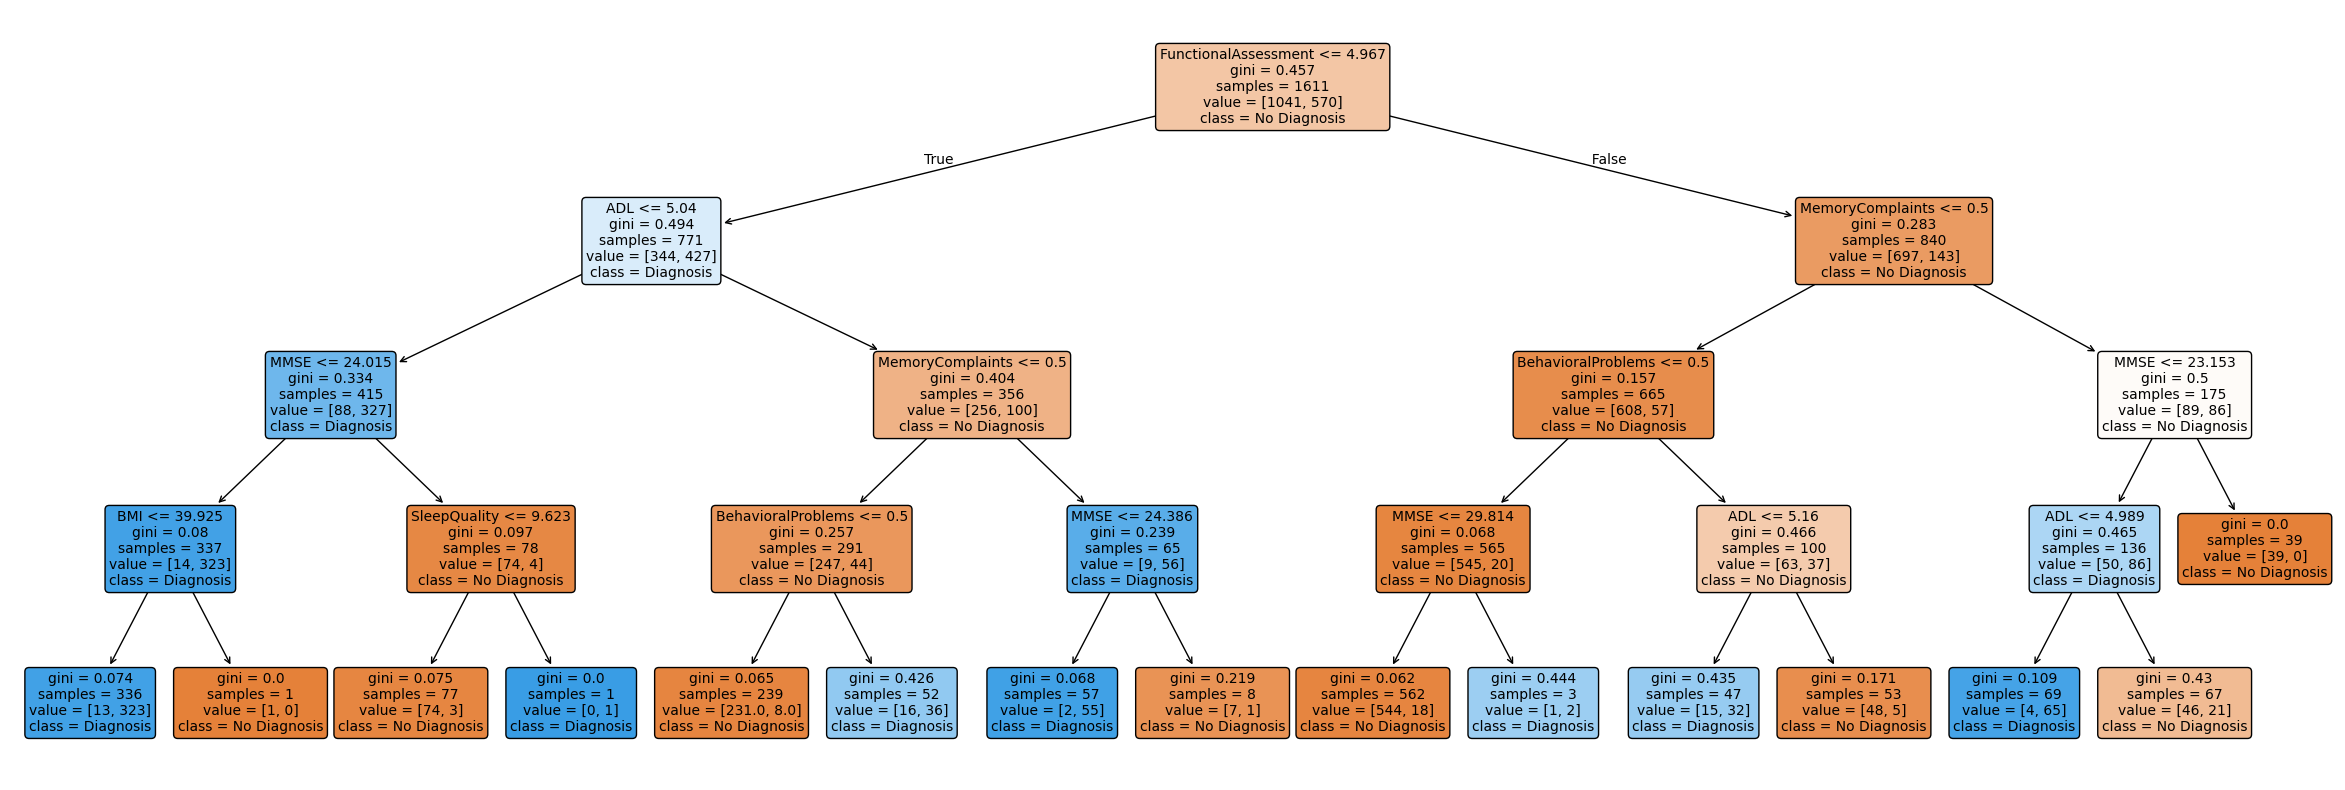

In [60]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(Xtrain, ytrain)

plt.figure(figsize=(30, 10))
plot_tree(dt, feature_names=X.columns, class_names=['No Diagnosis', 'Diagnosis'], 
          filled=True, rounded=True, fontsize=10)
plt.show()

> **Interpretation.** - The **root split is FunctionalAssessment <= 4.97**. Patients with low scores (771 patients) are mostly positive (427 of 771); those with higher scores (840 patients) are mostly negative (697 of 840).
> - On the low-score branch, **ADL <= 5.04** and **MMSE <= 24.0** identify a group of 337 patients of whom 323 (96%) are positive.
> - On the high-score branch, having **no memory complaints and no behavioural problems** leaves a group of 565 patients of whom 545 (96%) are negative.
> - The tree uses only FunctionalAssessment, ADL, MMSE, MemoryComplaints and BehavioralProblems (plus tiny leaves on BMI and SleepQuality), matching the correlations in Cell 18.
> - This tree is for explanation only; it is not evaluated on the test set.

####  XGBoost feature importance

> Plots the 15 most important features of the tuned XGBoost model. XGBoost's default importance type is **weight**: the number of times a feature is used in a split across all trees.

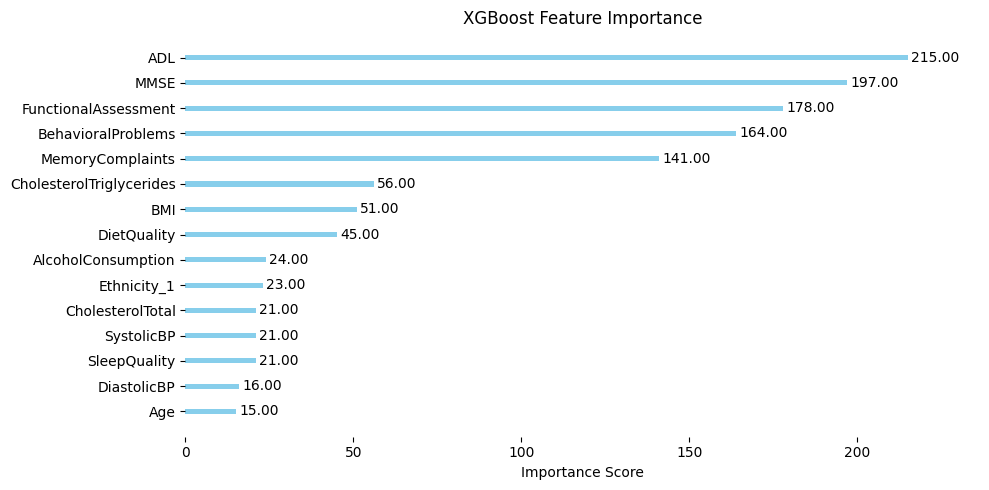

In [61]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_importance(xgb_cv.best_estimator_, 
                 max_num_features=15,
                 color='#87CEEB',
                 title='XGBoost Feature Importance',
                 xlabel='Importance Score',
                 ylabel='',
                 ax=ax,
                 grid=False,
                 values_format='{v:.2f}')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

> **Interpretation.** The top five are **ADL (215), MMSE (197), FunctionalAssessment (178), BehavioralProblems (164) and MemoryComplaints (141)**, the same variables that stood out in the correlations and the decision tree. Everything after them (triglycerides, diet quality, BMI, sleep quality and so on) scores 56 or lower and is probably noise splits. Note that split-count importance favours continuous variables that offer many possible split points. Permutation importance or SHAP values would give a more reliable ranking.

## Part 8: Risk-factor-only experiment 

> Drops the five strongest predictors (FunctionalAssessment, ADL, MMSE, MemoryComplaints, BehavioralProblems), re-splits with the same settings, and retrains XGBoost with the previously tuned parameters. This tests whether lifestyle, demographic and medical-history factors alone can predict diagnosis.

In [62]:
excluded_cols = ['FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 'BehavioralProblems']

X_risk_only = X.drop(columns=excluded_cols)
Xtrain_r, Xtest_r, ytrain_r, ytest_r = train_test_split(
    X_risk_only, y, test_size=0.25, stratify=y, random_state=42
)

xgb_risk = XGBClassifier(objective='binary:logistic', random_state=0, eval_metric='logloss',
                          **xgb_cv.best_params_)
xgb_risk.fit(Xtrain_r, ytrain_r)

risk_preds = xgb_risk.predict(Xtest_r)
print('Risk-factor-only F1:', f1_score(ytest_r, risk_preds))
print('Risk-factor-only Accuracy:', accuracy_score(ytest_r, risk_preds))

Risk-factor-only F1: 0.030303030303030304
Risk-factor-only Accuracy: 0.6431226765799256


> **Interpretation.** **F1 collapses from 0.936 to 0.104 and accuracy falls from 0.955 to 0.617.** Accuracy of 0.617 is actually *below* the 64.7% you would get by always predicting 'negative' (348 of 538). The remaining variables contain almost no usable signal in this dataset. Note also that the five removed variables are clinical assessment and symptom measures, so much of the model's earlier strength may reflect recognising an existing diagnosis rather than forecasting risk.

In [63]:
print(classification_report(ytest_r, risk_preds))
print(confusion_matrix(ytest_r, risk_preds))

              precision    recall  f1-score   support

           0       0.65      0.99      0.78       348
           1       0.38      0.02      0.03       190

    accuracy                           0.64       538
   macro avg       0.51      0.50      0.41       538
weighted avg       0.55      0.64      0.52       538

[[343   5]
 [187   3]]



> **Interpretation.** -Class 0 (negative): precision 0.65, recall 0.99. Class 1 (positive): **precision 0.38, recall 0.02, F1 0.03.**
> -The confusion matrix [[343, 5], [187, 3]] shows the model found only 3 of 190 positive patients and missed 187.
> -The model has effectively learned to say 'negative' almost every time, which is the best it can do when the inputs carry no signal.

In [64]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)

xgb_risk_cv = RandomizedSearchCV(
    XGBClassifier(objective='binary:logistic', random_state=0, eval_metric='logloss'),
    cv_params, n_iter=30, scoring=scoring, cv=5, refit='f1', random_state=42
)
xgb_risk_cv.fit(Xtrain_r, ytrain_r)

risk_preds_tuned = xgb_risk_cv.predict(Xtest_r)
print(classification_report(ytest_r, risk_preds_tuned))

              precision    recall  f1-score   support

           0       0.63      0.81      0.71       348
           1       0.29      0.14      0.19       190

    accuracy                           0.58       538
   macro avg       0.46      0.48      0.45       538
weighted avg       0.51      0.58      0.53       538



> **Interpretation.** Positive-class recall rises slightly to 0.14 and F1 to 0.19, but overall accuracy drops to 0.58, still below the 65% baseline. Tuning cannot create signal that is not in the data, which reinforces the Cell 44-45 conclusion.

## Part 9: ROC-AUC model comparison

In [65]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get predicted probabilities for the positive class (Diagnosis = 1) from each model
logreg_probs = logreg_cv.predict_proba(Xtest_scaled)[:, 1]
rf_probs = randomforest.predict_proba(Xtest)[:, 1]
xgb_probs = xgb_cv.predict_proba(Xtest)[:, 1]

# Compute ROC-AUC score for each
logreg_auc = roc_auc_score(ytest, logreg_probs)
rf_auc = roc_auc_score(ytest, rf_probs)
xgb_auc = roc_auc_score(ytest, xgb_probs)

print('Logistic Regression ROC-AUC:', logreg_auc)
print('Random Forest ROC-AUC:', rf_auc)
print('XGBoost ROC-AUC:', xgb_auc)

Logistic Regression ROC-AUC: 0.894751966122202
Random Forest ROC-AUC: 0.9433454325468844
XGBoost ROC-AUC: 0.9441394434361768


#### ROC curves plot

> Draws each model's ROC curve (true-positive rate vs false-positive rate across all thresholds) with a dashed diagonal representing random guessing.

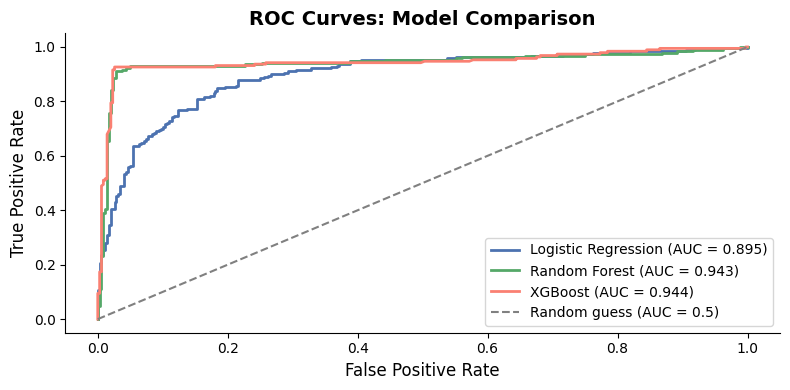

In [66]:
plt.figure(figsize=(8, 4))

for probs, auc, label, color in [
    (logreg_probs, logreg_auc, 'Logistic Regression', '#4C72B0'),
    (rf_probs, rf_auc, 'Random Forest', '#55A868'),
    (xgb_probs, xgb_auc, 'XGBoost', '#FA8072')
]:
    fpr, tpr, _ = roc_curve(ytest, probs)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')

plt.title('ROC Curves: Model Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

> **Interpretation.** The XGBoost and Random Forest curves almost overlap and shoot up steeply: at a false-positive rate of only about 3% they already catch about 92% of true positives (AUC 0.944 and 0.943). Logistic Regression (AUC 0.895) needs a much higher false-positive rate for the same sensitivity (for example, it reaches about 85% true positives only at roughly 20% false positives, versus about 93% for the tree models). All curves are far above the random-guess diagonal.

## Overall summary and caveats

**Model ranking (test set).** XGBoost: accuracy 0.954, F1 0.933, recall 0.916, precision 0.951, AUC 0.949. Random Forest: accuracy 0.924, F1 0.884, AUC 0.943. Logistic Regression: accuracy 0.831, F1 0.756, AUC 0.895. Cross-validation and test scores agree closely, so the results look stable rather than overfit.

**What drives the predictions.** FunctionalAssessment, ADL, MMSE, MemoryComplaints and BehavioralProblems. Lifestyle, demographic, cholesterol, blood pressure and medical-history variables show essentially no association with diagnosis, including age.

**Caveat 1 - what the model is really predicting.** The five key variables are clinical assessment and symptom measures. A model built on them mostly *recognises* an existing diagnosis; it is not a forecast of who will develop Alzheimer's. The risk-factor-only experiment (Cells 44-46) shows that without them the model does no better than guessing.

**Caveat 2 - the data look synthetic.** Many variables are evenly (uniformly) spread over their ranges, predictors are almost uncorrelated with each other, and age has zero correlation with diagnosis. Please confirm the dataset's provenance; these results should not be assumed to transfer to real clinical populations.

**Caveat 3 - evaluation.** A single 75/25 split with 190 test positives gives fairly wide uncertainty on every metric. Repeated cross-validation or bootstrapped confidence intervals would tell you whether XGBoost and Random Forest are truly different.

**Suggested improvements.** Print `best_params_` for each search; consider tuning the decision threshold to raise recall if missed cases are costly; use permutation importance or SHAP instead of split counts; fix the gender legend in Cell 12; run the cells in notebook order (or move Cell 13 after the encoding step) so the output matches the code position; and use `ignore_index=True` when concatenating result tables.

*This analysis is an educational data-science exercise and is not a validated clinical tool or medical advice.*